# 🧪 AirLyst: Top 3 Models Deep Evaluation
**Mission: Deep dive into the performance of LightGBM, Random Forest, and XGBoost.**

---

In [ ]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

os.environ['LOKY_MAX_CPU_COUNT'] = '4' 
ROOT_DIR = Path("C:/Users/Dell/Desktop/AirLyst")
sys.path.append(str(ROOT_DIR))

print("✅ Evaluation Ready.")

## 📊 1. Data Loading

In [ ]:
df = pd.read_csv(ROOT_DIR / "backend/data/engineered_features.csv")
df = df.sort_values('time').dropna()

feature_cols = ['temperature_2m', 'surface_pressure', 'wind_speed_10m', 'hour', 'day_of_week', 'is_weekend', 'pm2_5_lag_1h', 'us_aqi_lag_1h']
target_col = 'us_aqi'

split = int(len(df) * 0.8)
train_df, test_df = df.iloc[:split], df.iloc[split:]

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_test, y_test = test_df[feature_cols], test_df[target_col]

## 🛠️ 2. Training & Sample Predictions

In [35]:
models = {
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, verbose=-1),
    'Random Forest': RandomForestRegressor(n_estimators=100),
    'XGBoost': xgb.XGBRegressor(n_estimators=100)
}

predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)

print("--- 📋 Sample: Actual vs Predicted (Terminal-Style Output) ---")
sample_comparison = pd.DataFrame({'Actual': y_test}).reset_index(drop=True)
for name, p in predictions.items():
    sample_comparison[name] = p.round(2)

display(sample_comparison.head(15))

--- 📋 Sample: Actual vs Predicted (Terminal-Style Output) ---


,Actual,LightGBM,Random Forest,XGBoost
0,127,129.43,128.98,128.839996
1,125,127.12,127.96,126.500000
2,124,125.68,129.82,125.139999
3,125,123.85,123.78,123.870003
4,124,124.67,124.80,124.269997
5,124,123.37,124.03,123.989998
6,125,123.53,124.51,123.320000
7,126,124.91,125.60,123.709999
8,127,125.76,126.74,125.879997
9,131,127.92,127.96,128.610001


## 📉 3. Quantitative Comparison

In [34]:
stats = []
for name, p in predictions.items():
    mae = mean_absolute_error(y_test, p)
    rmse = np.sqrt(mean_squared_error(y_test, p))
    r2 = r2_score(y_test, p)
    stats.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2 Score': r2})

df_stats = pd.DataFrame(stats).sort_values('MAE')
display(df_stats)

,Model,MAE,RMSE,R2 Score
0,LightGBM,2.243033,4.408123,0.971079
1,Random Forest,2.299844,4.606812,0.968413
2,XGBoost,2.391875,4.505777,0.969783


## 🎨 4. Visual Diagnostics

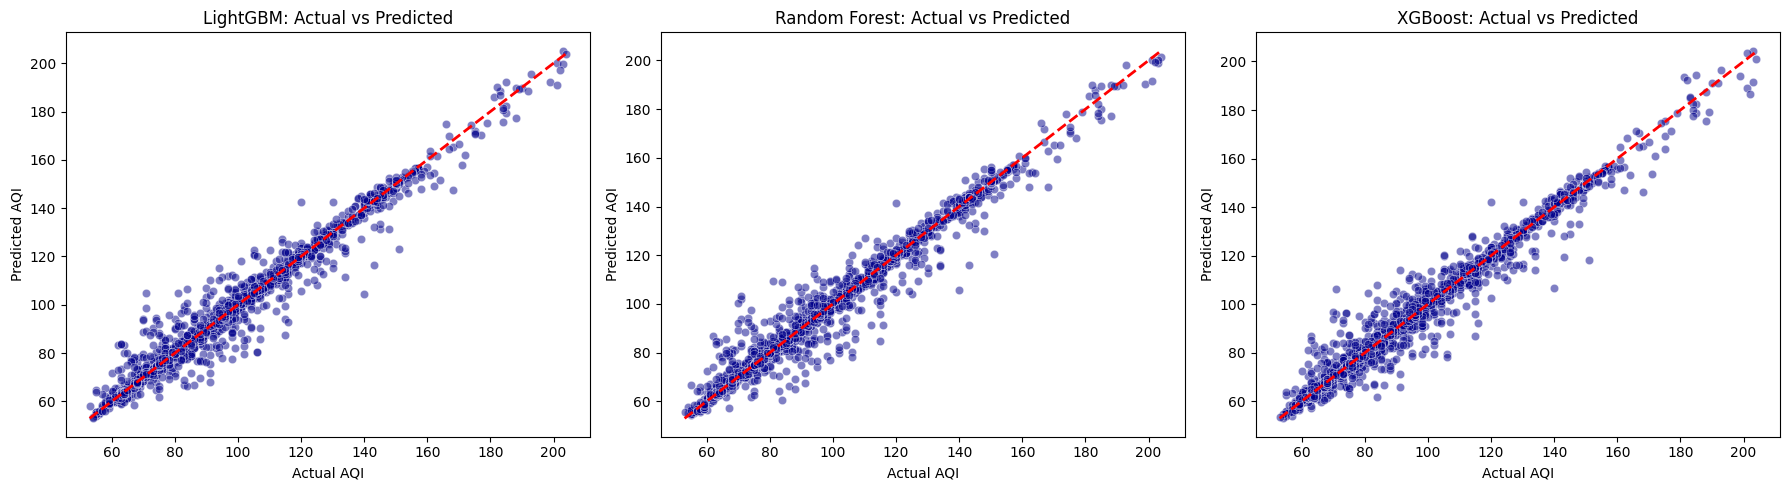

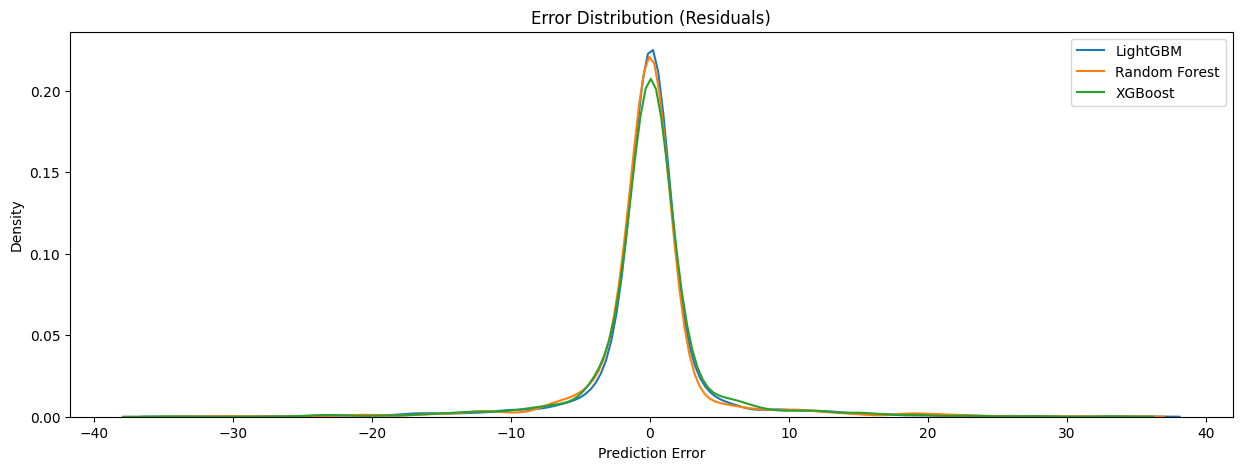

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, p) in enumerate(predictions.items()):
    sns.scatterplot(x=y_test, y=p, ax=axes[i], alpha=0.5, color='darkblue')
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
    axes[i].set_title(f"{name}: Actual vs Predicted")
    axes[i].set_xlabel("Actual AQI")
    axes[i].set_ylabel("Predicted AQI")

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))
for name, p in predictions.items():
    residuals = y_test - p
    sns.kdeplot(residuals, label=name)
plt.title("Error Distribution (Residuals)")
plt.xlabel("Prediction Error")
plt.legend()
plt.show()